# E-Commerce Sales Analysis

## Project Overview

This project analyzes transactional e-commerce data to evaluate sales performance, cancellations and returns, product demand, country-level revenue, and customer purchasing behavior.

## Business Questions

- What are the gross and net sales?
- How much revenue is reduced by cancellations and returns?
- Which months and countries generate the most revenue?
- Which products generate the highest net sales?
- Who are the most valuable customers?
- Which customers have the highest average order value?

## 1. Data Loading

The dataset contains transactional records from an online retailer. Each row represents a single product line within an invoice, meaning that one invoice may appear across multiple rows.

The dataset includes invoice identifiers, product codes and descriptions, quantities, transaction dates, unit prices, customer identifiers, and countries.

The CSV file is loaded using `ISO-8859-1` encoding to correctly read special characters in the dataset.

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#reading CSV file into data frame
df = pd.read_csv(
    'data.csv',
    encoding='ISO-8859-1'
)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


## 2. Initial Data Overview

Before cleaning the data, an initial inspection is performed to understand its structure, dimensions, column names, data types, and missing values.

This step helps identify potential data quality issues that require further investigation.

In [4]:
display(df.head())

print(f'Number of rows: {df.shape[0]:,}')
print(f'Number of columns: {df.shape[1]}')
print(f'Columns: {df.columns.tolist()}')

df.info()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Number of rows: 541,909
Number of columns: 8
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 59.5 MB


## 3. Data Quality Assessment

The dataset is evaluated for missing values, duplicate records, invalid quantities and prices, and cancellation transactions before creating the final analytical datasets.

### 3.1 Missing Values

Missing values are examined to determine which columns are affected and whether they should be removed, retained, or handled differently depending on the analysis.

In [5]:
missing_values = (
    df.isna()
    .sum()
    .reset_index(name='missing_count')
)

missing_values['missing_percentage'] = (
    missing_values['missing_count']
    / len(df)
    * 100
).round(2)


missing_values = missing_values.rename(
    columns={'index': 'column'}
)

missing_values

,column,missing_count,missing_percentage
0,InvoiceNo,0,0.00
1,StockCode,0,0.00
2,Description,1454,0.27
3,Quantity,0,0.00
4,InvoiceDate,0,0.00
5,UnitPrice,0,0.00
6,CustomerID,135080,24.93
7,Country,0,0.00


#### Missing Values Findings

- `Description` contains 1,454 missing values, representing approximately 0.27% of the dataset.
- `CustomerID` contains 135,080 missing values, representing approximately 24.93% of the dataset.
- The remaining columns contain no missing values.
- Missing customer identifiers are retained for overall sales, product, and country analysis because the transactions may still contain useful information.
- Rows without a customer identifier are excluded only from customer-level analysis.
- Missing product descriptions require further investigation before deciding whether to remove them.

### 3.2 Duplicate Records

Exact duplicate rows are inspected because repeated transaction records can overstate quantities, invoice activity, and revenue.

Two measurements are used:

- The number of rows identified as additional duplicate copies.
- The total number of rows involved in duplicate groups, including the first occurrence.

In [6]:
duplicate_count = df.duplicated().sum()

duplicate_group_rows = df.duplicated(
    keep=False
).sum()

print(f'Additional duplicate rows: {duplicate_count:,}')
print(
    'Total rows involved in duplicate groups: '
    f'{duplicate_group_rows:,}'
)

duplicated_rows = (
    df[df.duplicated(keep=False)]
    .sort_values('InvoiceNo')
)

display(duplicated_rows.head(10))

Additional duplicate rows: 5,268
Total rows involved in duplicate groups: 10,147


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


#### Duplicate Findings

- The dataset contains 5,268 exact duplicate rows.
- A total of 10,147 rows are involved in duplicate groups when the original occurrences are included.
- Exact duplicate copies will be removed to prevent quantities and revenue from being counted more than once.

### 3.3 Numerical Anomalies and Cancellations

The numerical columns are inspected for negative, zero, and unusually large values.

Negative quantities may represent cancellations, returns, damaged products, missing inventory, or manual stock adjustments. Negative unit prices may represent accounting adjustments rather than normal product transactions.

In [7]:
df[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [8]:
negative_quantity_count = (df['Quantity'] < 0).sum()
zero_quantity_count = (df['Quantity'] == 0).sum()

negative_price_count = (df['UnitPrice'] < 0).sum()
zero_price_count = (df['UnitPrice'] == 0).sum()

cancellation_count = (
    df['InvoiceNo']
    .str.startswith('C', na=False)
    .sum()
)

print('Negative quantities:', negative_quantity_count)
print('Zero quantities:', zero_quantity_count)
print('Negative prices:', negative_price_count)
print('Zero prices:', zero_price_count)
print('Cancellation rows:', cancellation_count)

Negative quantities: 10624
Zero quantities: 0
Negative prices: 2
Zero prices: 2515
Cancellation rows: 9288


In [9]:
df[df['Quantity'] < 0][['InvoiceNo','Quantity','Description','UnitPrice']].head(20)

,InvoiceNo,Quantity,Description,UnitPrice
141,C536379,-1,Discount,27.50
154,C536383,-1,SET OF 3 COLOURED FLYING DUCKS,4.65
235,C536391,-12,PLASTERS IN TIN CIRCUS PARADE,1.65
236,C536391,-24,PACK OF 12 PINK PAISLEY TISSUES,0.29
237,C536391,-24,PACK OF 12 BLUE PAISLEY TISSUES,0.29
238,C536391,-24,PACK OF 12 RED RETROSPOT TISSUES,0.29
239,C536391,-12,CHICK GREY HOT WATER BOTTLE,3.45
240,C536391,-12,PLASTERS IN TIN VINTAGE PAISLEY,1.65
241,C536391,-24,PLASTERS IN TIN SKULLS,1.65
939,C536506,-6,JAM MAKING SET WITH JARS,4.25


In [10]:
df[df['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [11]:
negative_non_cancellation = df[
    (df['Quantity'] < 0)
    & (~df['InvoiceNo'].str.startswith('C', na=False))
]

print(
    'Negative quantity rows not starting with C:',
    len(negative_non_cancellation)
)

display(negative_non_cancellation.head(10))


Negative quantity rows not starting with C: 1336


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom


#### Anomaly Findings

- The dataset contains 10,624 rows with negative quantities.
- A total of 9,288 rows belong to invoice numbers starting with `C`, indicating cancellations or returns.
- The remaining 1,336 negative-quantity rows do not start with `C`. Their descriptions include terms such as `lost`, `missing`, `damaged`, and `check`, suggesting internal inventory adjustments.
- No rows contain a quantity equal to zero.
- Two rows contain negative unit prices. Both are labeled as bad-debt adjustments rather than normal product transactions.
- A total of 2,515 rows have a unit price equal to zero and therefore do not directly generate revenue.
- Negative quantities will be retained when calculating net sales so that cancellations and returns reduce revenue correctly.


## 4. Data Cleaning

The cleaning process creates reliable datasets for analysis while preserving important business information such as cancellations and returns.

### 4.1 Removing Exact Duplicates

Exact duplicate rows are removed to prevent the same transaction records from being counted more than once.

In [12]:
df_clean = (
    df.copy()
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f'Original rows: {len(df):,}')
print(f'Clean rows: {len(df_clean):,}')
print(f'Removed duplicate rows: {len(df) - len(df_clean):,}')
print(f'Remaining duplicates: {df_clean.duplicated().sum()}')

Original rows: 541,909
Clean rows: 536,641
Removed duplicate rows: 5,268
Remaining duplicates: 0


#### Duplicate Removal Result

- The dataset was reduced from 541,909 to 536,641 rows.
- A total of 5,268 exact duplicate rows were removed.
- No exact duplicate rows remain in the cleaned dataset.

### 4.2 Missing Product Descriptions

Rows with missing product descriptions are investigated before deciding whether to remove them.

Their prices, customer identifiers, countries, and quantities are examined to determine whether they represent real customer sales or internal inventory activity.

In [13]:
missing_description = df_clean[
    df_clean['Description'].isna()
].copy()

print(
    'Missing descriptions:',
    len(missing_description)
)

print(
    'Zero unit prices:',
    (missing_description['UnitPrice'] == 0).sum()
)

print(
    'Missing customer IDs:',
    missing_description['CustomerID'].isna().sum()
)

print(
    'Negative quantities:',
    (missing_description['Quantity'] < 0).sum()
)

print(
    'Positive quantities:',
    (missing_description['Quantity'] > 0).sum()
)

print('\nCountries:')
print(missing_description['Country'].value_counts())

display(missing_description.head(10))

Missing descriptions: 1454
Zero unit prices: 1454
Missing customer IDs: 1454
Negative quantities: 862
Positive quantities: 592

Countries:
Country
United Kingdom    1454
Name: count, dtype: int64


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
605,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1934,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1935,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1936,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1951,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1952,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1984,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1985,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
1986,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2362,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


#### Missing Description Findings

- All 1,454 rows with missing descriptions have a unit price equal to zero.
- All of these rows also have missing customer identifiers.
- All records belong to the United Kingdom.
- The rows contain both positive and negative quantities, suggesting internal stock movements or inventory adjustments rather than normal customer sales.
- These rows are retained in the cleaned base dataset for audit purposes but will not be included in revenue analysis because their unit price is zero.

### 4.3 Missing Customer Identifiers

Rows with missing customer identifiers are investigated separately.

These transactions may still be useful for overall revenue, country, and product analysis, but they cannot be assigned to a specific customer.

In [14]:
missing_customers = df_clean[
    df_clean['CustomerID'].isna()
].copy()

filtered_customers = missing_customers[
    (missing_customers['Quantity'] > 0)
    & (missing_customers['UnitPrice'] > 0)
].copy()

missing_customer_percentage = (
    len(missing_customers)
    / len(df_clean)
    * 100
)

print(
    'Missing customer IDs:',
    len(missing_customers)
)

print(
    'Missing customer percentage:',
    round(missing_customer_percentage, 2),
    '%'
)

print(
    'Positive quantities:',
    (missing_customers['Quantity'] > 0).sum()
)

print(
    'Negative quantities:',
    (missing_customers['Quantity'] < 0).sum()
)

print(
    'Positive quantity and price:',
    len(filtered_customers)
)

print('\nTop countries:')
print(
    filtered_customers['Country']
    .value_counts()
    .head(10)
)

display(filtered_customers.head(10))

Missing customer IDs: 135037
Missing customer percentage: 25.16 %
Positive quantities: 133322
Negative quantities: 1715
Positive quantity and price: 132186

Top countries:
Country
United Kingdom    130782
EIRE                 653
Hong Kong            280
Unspecified          201
Switzerland          117
France                66
Israel                47
Portugal              39
Bahrain                1
Name: count, dtype: int64


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1407,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1408,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1409,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1410,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1411,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1412,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1413,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1414,536544,21802,CHRISTMAS TREE HEART DECORATION,9,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1415,536544,21803,CHRISTMAS TREE STAR DECORATION,11,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1416,536544,21809,CHRISTMAS HANGING TREE WITH BELL,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom


#### Missing Customer Findings

- After removing duplicates, 135,037 rows have missing customer identifiers.
- A large majority of these rows contain positive quantities and positive unit prices, meaning that they may represent valid sales transactions.
- These records are retained for overall revenue, product, country, and time-based analysis.
- They are excluded only from customer-level analysis because they cannot be linked to a specific customer.
- Missing customer identifiers are not filled because there is no reliable way to infer the correct customer.

### 4.4 Creating the Gross Sales Dataset

A gross sales dataset is created to analyze completed positive sales before subtracting returns and cancellations.

Only rows with positive quantities, positive unit prices, and invoice numbers that do not start with `C` are included.

In [15]:
sales_df = df_clean[
    (df_clean['Quantity'] > 0)
    & (df_clean['UnitPrice'] > 0)
    & (~df_clean['InvoiceNo'].str.startswith('C', na=False))
].copy()

sales_df.reset_index(
    drop=True,
    inplace=True
)

sales_df['CustomerID'] = (
    sales_df['CustomerID']
    .astype('Int64')
)

sales_df['TotalPrice'] = (
    sales_df['Quantity']
    * sales_df['UnitPrice']
)

In [16]:
print('Gross sales rows:', len(sales_df))

print(
    'Invoices starting with C:',
    sales_df['InvoiceNo']
    .str.startswith('C', na=False)
    .sum()
)

print(
    'Minimum quantity:',
    sales_df['Quantity'].min()
)

print(
    'Minimum unit price:',
    sales_df['UnitPrice'].min()
)

gross_sales = sales_df['TotalPrice'].sum()

print(
    'Gross sales:',
    round(gross_sales, 2)
)

display(sales_df.head())

Gross sales rows: 524878
Invoices starting with C: 0
Minimum quantity: 1
Minimum unit price: 0.001
Gross sales: 10642110.8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


#### Gross Sales Dataset Result

- The gross sales dataset contains 524,878 transaction rows.
- All quantities and unit prices are greater than zero.
- No cancellation invoices starting with `C` are included.
- Gross sales before subtracting returns and cancellations are approximately 10.64 million.
- Transactions with missing customer identifiers remain included because they are still useful for overall sales analysis.

### 4.5 Creating the Net Sales Dataset

A net sales dataset is created by retaining negative quantities so that cancellations and returns reduce revenue.

Rows with zero or negative unit prices are excluded because they do not represent normal revenue-generating product transactions. Cancellation invoices are retained in this dataset.

In [17]:
net_sales_df = df_clean[
    df_clean['UnitPrice'] > 0
].copy()

net_sales_df['CustomerID'] = (
    net_sales_df['CustomerID']
    .astype('Int64')
)

net_sales_df['TotalPrice'] = (
    net_sales_df['Quantity']
    * net_sales_df['UnitPrice']
)

net_sales = net_sales_df['TotalPrice'].sum()

revenue_reduction = gross_sales - net_sales

reduction_percentage = (
    revenue_reduction
    / gross_sales
    * 100
)

In [18]:
print(
    'Gross sales:',
    round(gross_sales, 2)
)

print(
    'Net sales:',
    round(net_sales, 2)
)

print(
    'Revenue reduction:',
    round(revenue_reduction, 2)
)

print(
    'Reduction percentage:',
    round(reduction_percentage, 2),
    '%'
)

Gross sales: 10642110.8
Net sales: 9748131.07
Revenue reduction: 893979.73
Reduction percentage: 8.4 %


#### Net Sales Dataset Result

- Gross sales are approximately 10.64 million.
- After accounting for cancellations and returns, net sales are approximately 9.75 million.
- Cancellations and returns reduce revenue by approximately 893,979.73.
- This represents approximately 8.4% of gross sales.
- The gross dataset is used to analyze positive sales activity, while the net dataset is used when the financial impact of returns and cancellations must be included.

## 5. Sales Analysis

This section analyzes sales performance over time and across countries, products, and customers.

### 5.1 Monthly Net Sales

Monthly net sales are calculated after including the financial impact of cancellations and returns.

The results are kept in chronological order to show how revenue changes over time.

In [19]:
net_sales_df['Year'] = (
    net_sales_df['InvoiceDate']
    .dt.year
)

net_sales_df['Month'] = (
    net_sales_df['InvoiceDate']
    .dt.month
)

monthly_net_sales = (
    net_sales_df
    .groupby(
        ['Year', 'Month'],
        as_index=False
    )['TotalPrice']
    .sum()
)

monthly_net_sales['TotalPrice'] = (
    monthly_net_sales['TotalPrice']
    .round(2)
)

monthly_net_sales = (
    monthly_net_sales
    .sort_values(['Year', 'Month'])
    .reset_index(drop=True)
)

monthly_net_sales

,Year,Month,TotalPrice
0,2010,12,746723.61
1,2011,1,558448.56
2,2011,2,497026.41
3,2011,3,682013.98
4,2011,4,492367.84
5,2011,5,722094.10
6,2011,6,689977.23
7,2011,7,680156.99
8,2011,8,703510.58
9,2011,9,1017596.68


In [20]:
top_months = (
    monthly_net_sales
    .sort_values(
        'TotalPrice',
        ascending=False
    )
    .head(3)
    .reset_index(drop=True)
)

top_months

,Year,Month,TotalPrice
0,2011,11,1456145.80
1,2011,10,1069368.23
2,2011,9,1017596.68


In [21]:
print(
    'First transaction:',
    net_sales_df['InvoiceDate'].min()
)

print(
    'Last transaction:',
    net_sales_df['InvoiceDate'].max()
)

First transaction: 2010-12-01 08:26:00
Last transaction: 2011-12-09 12:50:00


#### Monthly Sales Findings

- November 2011 generated the highest monthly net sales at approximately 1.46 million.
- October 2011 ranked second with approximately 1.07 million in net sales.
- September 2011 ranked third with approximately 1.02 million.
- The strongest sales months are concentrated between September and November, suggesting increased demand toward the end of the year.
- The dataset covers the period from December 1, 2010, to December 9, 2011.
- December 2011 is incomplete and should not be directly compared with full months.

### 5.2 Country Net Sales

Net sales are grouped by country to identify the markets generating the most revenue after accounting for cancellations and returns.

In [22]:
country_net_sales = (
    net_sales_df
    .groupby(
        'Country',
        as_index=False
    )['TotalPrice']
    .sum()
)

country_net_sales['TotalPrice'] = (
    country_net_sales['TotalPrice']
    .round(2)
)

country_net_sales = (
    country_net_sales
    .sort_values(
        'TotalPrice',
        ascending=False
    )
    .reset_index(drop=True)
)

country_net_sales.head(10)

,Country,TotalPrice
0,United Kingdom,8189252.30
1,Netherlands,284661.54
2,EIRE,262993.38
3,Germany,221509.47
4,France,197317.11
5,Australia,137009.77
6,Switzerland,56363.05
7,Spain,54756.03
8,Belgium,40910.96
9,Sweden,36585.41


In [23]:
uk_net_sales = country_net_sales.loc[
    country_net_sales['Country'] == 'United Kingdom',
    'TotalPrice'
].iloc[0]

uk_sales_percentage = (
    uk_net_sales
    / net_sales
    * 100
)

print(
    'United Kingdom net sales:',
    round(uk_net_sales, 2)
)

print(
    'United Kingdom share:',
    round(uk_sales_percentage, 2),
    '%'
)

United Kingdom net sales: 8189252.3
United Kingdom share: 84.01 %


#### Country Sales Findings

- The United Kingdom generates approximately 8.19 million in net sales.
- It represents approximately 84% of total net sales, making it the dominant market in the dataset.
- The Netherlands ranks second, followed by EIRE, Germany, and France.
- Revenue is highly concentrated in the United Kingdom, indicating significant dependence on one market.
- When visualizing country performance, the United Kingdom should also be excluded in a separate chart so that differences between the remaining countries can be seen clearly.

### 5.3 Gross vs Net Product Sales

Product performance is first calculated using positive gross sales.

Shipping charges and manual accounting entries are excluded because they do not represent physical products. Gross product sales are then compared with net product sales to understand the effect of cancellations and returns.

In [24]:
gross_products_df = sales_df[
    ~sales_df['StockCode'].str.upper().isin(
        ['DOT', 'POST', 'M']
    )
].copy()

gross_product_sales = (
    gross_products_df
    .groupby(
        ['StockCode', 'Description'],
        as_index=False
    )[['Quantity', 'TotalPrice']]
    .sum()
)

gross_product_sales['TotalPrice'] = (
    gross_product_sales['TotalPrice']
    .round(2)
)

gross_product_sales = (
    gross_product_sales
    .sort_values(
        'TotalPrice',
        ascending=False
    )
    .reset_index(drop=True)
)

gross_product_sales.head(10)

,StockCode,Description,Quantity,TotalPrice
0,22423,REGENCY CAKESTAND 3 TIER,13851,174156.54
1,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580,104284.24
3,47566,PARTY BUNTING,18283,99445.23
4,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81
5,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92
6,23084,RABBIT NIGHT LIGHT,30739,66870.03
7,22086,PAPER CHAIN KIT 50'S CHRISTMAS,19329,64875.59
8,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62
9,79321,CHILLI LIGHTS,10302,54096.36


#### Investigating an Unusually Large Transaction

Product `23843` appears among the highest-grossing products because 80,995 units were recorded in a single transaction.

The original cleaned dataset is examined to determine whether the transaction was later cancelled.

In [25]:
product_23843 = df_clean[
    df_clean['StockCode'] == '23843'
][
    [
        'InvoiceNo',
        'StockCode',
        'Description',
        'Quantity',
        'UnitPrice',
        'InvoiceDate',
        'CustomerID',
        'Country'
    ]
].sort_values('InvoiceDate')

product_23843

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,InvoiceDate,CustomerID,Country
535160,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,2011-12-09 09:15:00,16446.0,United Kingdom
535161,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2.08,2011-12-09 09:27:00,16446.0,United Kingdom


#### Transaction Investigation Findings

- Invoice `581483` recorded a sale of 80,995 units at a unit price of 2.08.
- Twelve minutes later, invoice `C581484` recorded the same quantity as a negative value.
- Both records belong to the same product and customer.
- The positive and negative transaction values cancel each other, producing net sales of zero.
- This demonstrates why gross sales alone can overstate product performance when cancellations are ignored.

#### Net Product Sales

Net product sales are calculated using transactions with positive unit prices while retaining negative quantities from cancellations and returns.

Shipping charges and manual accounting entries are excluded because they do not represent physical products.

In [26]:
net_products_df = net_sales_df[
    ~net_sales_df['StockCode'].str.upper().isin(
        ['POST', 'DOT', 'M']
    )
].copy()

net_product_sales  = net_products_df.groupby(
    ['StockCode', 'Description']
    )[
        ['Quantity', 'TotalPrice']
].sum()


net_product_sales = net_product_sales.sort_values(
    'TotalPrice',
    ascending=False
)

net_product_sales.head(10)

,,Quantity,TotalPrice
StockCode,Description,,
22423,REGENCY CAKESTAND 3 TIER,12996,164459.49
47566,PARTY BUNTING,18006,98243.88
85123A,WHITE HANGING HEART T-LIGHT HOLDER,35002,97659.94
85099B,JUMBO BAG RED RETROSPOT,47256,92175.79
23084,RABBIT NIGHT LIGHT,30631,66661.63
22086,PAPER CHAIN KIT 50'S CHRISTMAS,18876,63715.24
84879,ASSORTED COLOUR BIRD ORNAMENT,36282,58792.42
79321,CHILLI LIGHTS,10222,53746.66
23298,SPOTTY BUNTING,8210,42030.67


#### Net Product Sales Findings

- `REGENCY CAKESTAND 3 TIER` is the highest-performing physical product, generating approximately 164,459.49 in net sales.
- `PARTY BUNTING` and `WHITE HANGING HEART T-LIGHT HOLDER` rank second and third.
- Product `23843` no longer appears among the top products because its entire recorded sale was cancelled.
- Comparing gross and net product sales prevents cancelled transactions from overstating product performance.

### 5.4 Customer Analysis

Customer-level analysis is performed using net sales, so cancellations and returns are included in each customer's financial activity.

Transactions with missing customer identifiers are excluded because they cannot be linked to a specific customer.

In [27]:
customer_df = net_sales_df.copy()

customer_df['CustomerID'] = customer_df['CustomerID'].astype('Int64')

customer_df = customer_df.dropna(subset=['CustomerID'])

customer_df.reset_index(
    drop=True,
    inplace=True
)

customer_summary_df = customer_df.groupby('CustomerID').agg(
    net_sales = ('TotalPrice', 'sum'),
    total_quantity = ('Quantity', 'sum'),
    invoice_count = ('InvoiceNo', 'nunique')
).sort_values('net_sales', ascending=False).reset_index()

customer_summary_df.head(10)

,CustomerID,net_sales,total_quantity,invoice_count
0,14646,279489.02,196143,76
1,18102,256438.49,64122,62
2,17450,187322.17,69009,55
3,14911,132458.73,76905,248
4,12415,123725.45,76946,26
5,14156,113214.59,56908,66
6,17511,88125.38,63012,46
7,16684,65892.08,49390,31
8,13694,62690.54,61899,60
9,15311,59284.19,37673,118


#### Purchase Invoice Count

The current invoice count includes both purchase and cancellation invoices.

A separate purchase invoice count is calculated by excluding invoice numbers that start with `C`. This count will be used to calculate the average order value.

In [28]:
purchase_df = customer_df[
    (~customer_df['InvoiceNo'].str.startswith(
        'C',
        na=False
    ))
    & (customer_df['Quantity'] > 0)
].copy()

purchase_counts = (
    purchase_df
    .groupby('CustomerID')
    .agg(
        purchase_invoice_count=('InvoiceNo', 'nunique')
    )
    .reset_index()
)

customer_summary_df = customer_summary_df.merge(
    purchase_counts,
    on='CustomerID',
    how='left'
)

customer_summary_df['purchase_invoice_count'] = (
    customer_summary_df['purchase_invoice_count']
    .fillna(0)
    .astype('Int64')
)

customer_summary_df.head(10)

,CustomerID,net_sales,total_quantity,invoice_count,purchase_invoice_count
0,14646,279489.02,196143,76,73
1,18102,256438.49,64122,62,60
2,17450,187322.17,69009,55,46
3,14911,132458.73,76905,248,201
4,12415,123725.45,76946,26,21
5,14156,113214.59,56908,66,55
6,17511,88125.38,63012,46,31
7,16684,65892.08,49390,31,28
8,13694,62690.54,61899,60,50
9,15311,59284.19,37673,118,91


#### Average Order Value

Average order value is calculated by dividing each customer's net sales by the number of purchase invoices.

Customers with zero purchase invoices are assigned a missing value to prevent division by zero.

#### Customers with the Highest Average Order Value

Only customers with at least five purchase invoices are included to make the comparison more reliable.

In [29]:
customer_summary_df['avg_order_value'] = (
    customer_summary_df['net_sales']
    / customer_summary_df['purchase_invoice_count'].replace(0, np.nan)
).round(2)

customer_summary_df.head(10)

,CustomerID,net_sales,total_quantity,invoice_count,purchase_invoice_count,avg_order_value
0,14646,279489.02,196143,76,73,3828.62
1,18102,256438.49,64122,62,60,4273.97
2,17450,187322.17,69009,55,46,4072.22
3,14911,132458.73,76905,248,201,659.0
4,12415,123725.45,76946,26,21,5891.69
5,14156,113214.59,56908,66,55,2058.45
6,17511,88125.38,63012,46,31,2842.75
7,16684,65892.08,49390,31,28,2353.29
8,13694,62690.54,61899,60,50,1253.81
9,15311,59284.19,37673,118,91,651.47


In [30]:
top_avg_customers = (
    customer_summary_df[
        customer_summary_df['purchase_invoice_count'] >= 5
    ]
    .sort_values(
        'avg_order_value',
        ascending=False
    )
    .reset_index(drop=True)
)

top_avg_customers.head(10)

,CustomerID,net_sales,total_quantity,invoice_count,purchase_invoice_count,avg_order_value
0,12415,123725.45,76946,26,21,5891.69
1,18102,256438.49,64122,62,60,4273.97
2,17450,187322.17,69009,55,46,4072.22
3,14088,50415.49,12593,14,13,3878.11
4,14646,279489.02,196143,76,73,3828.62
5,12753,21024.01,11250,11,6,3504.0
6,14096,57120.91,16335,34,17,3360.05
7,17511,88125.38,63012,46,31,2842.75
8,13081,27964.48,18929,21,11,2542.23
9,12557,11990.96,4384,5,5,2398.19


#### Customer Analysis Findings

- Customer `14646` generates the highest net sales, with approximately 279,489.02.
- Customer `12415` has the highest average order value among customers with at least five purchases, averaging 5,891.69 per order.
- Customer `14911` has a high purchase frequency of 201 purchase invoices, but a lower average order value of 659.00.
- A customer with the highest total sales is not necessarily the customer with the highest average order value.
- Customer value can therefore be evaluated using both total net sales and average order value.

## 6. Data Visualization

This section visualizes the main sales findings to make trends and comparisons easier to understand.

### 6.1 Monthly Net Sales Trend

A line chart is used to show how net sales changed over time.

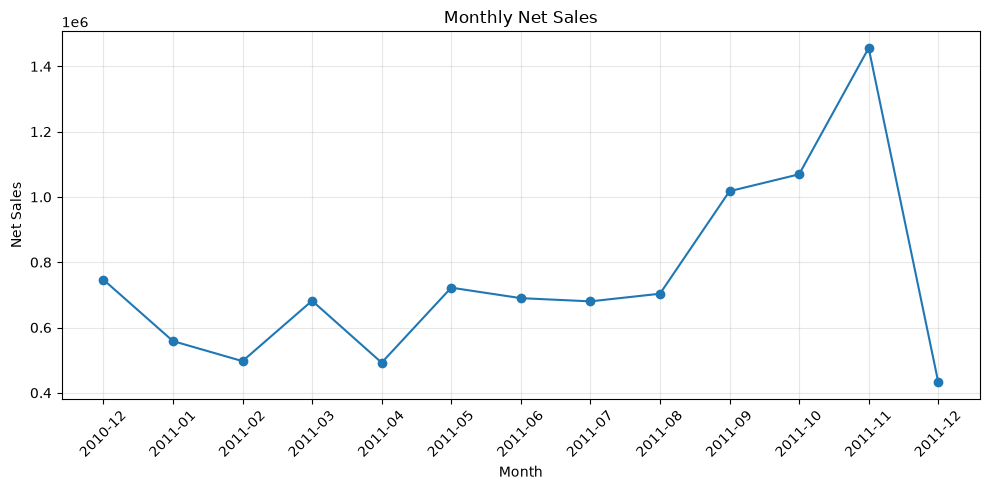

In [31]:
monthly_chart = monthly_net_sales.copy()

monthly_chart['YearMonth'] = (
    monthly_chart['Year'].astype(str)
    + '-'
    + monthly_chart['Month'].astype(str).str.zfill(2)
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_chart['YearMonth'],
    monthly_chart['TotalPrice'],
    marker='o'
)

plt.title('Monthly Net Sales')
plt.xlabel('Month')
plt.ylabel('Net Sales')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

#### Monthly Sales Findings

- Net sales increased significantly between September and November 2011.
- November 2011 recorded the highest monthly net sales at approximately 1.46 million.
- The sharp decline in December 2011 should not be interpreted as a performance decline because the dataset ends on 9 December 2011.
- November is therefore the strongest complete month in the dataset.

### 6.2 Net Sales by Country

The United Kingdom is excluded from this chart because its large share of total revenue makes differences between the remaining countries difficult to see.

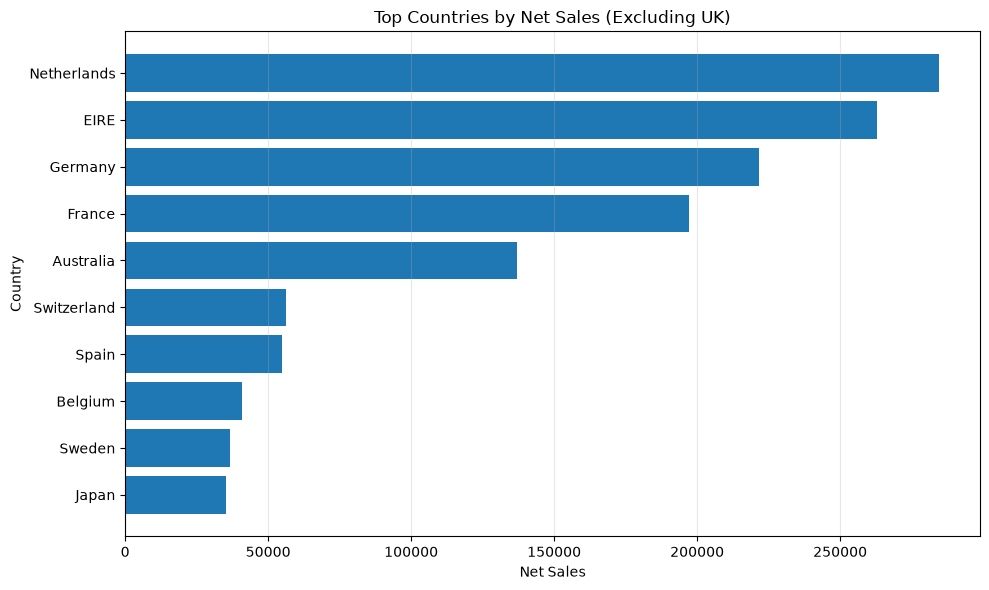

In [32]:
country_chart = country_net_sales[
    country_net_sales['Country'] != 'United Kingdom'
].head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    country_chart['Country'],
    country_chart['TotalPrice']
)

plt.gca().invert_yaxis()

plt.title('Top Countries by Net Sales (Excluding UK)')
plt.xlabel('Net Sales')
plt.ylabel('Country')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

plt.savefig('country_sales.png', dpi=150, bbox_inches='tight')
plt.show()

#### Country Sales Findings

- The Netherlands generates the highest net sales outside the United Kingdom, with approximately 284.7 thousand.
- EIRE ranks second, followed by Germany and France.
- Australia also represents a relatively strong market compared with the remaining countries.
- There is a noticeable revenue gap between Australia and the countries ranked below it.

### 6.3 Top Products by Net Sales

A horizontal bar chart is used to compare the ten physical products generating the highest net sales after accounting for cancellations and returns.

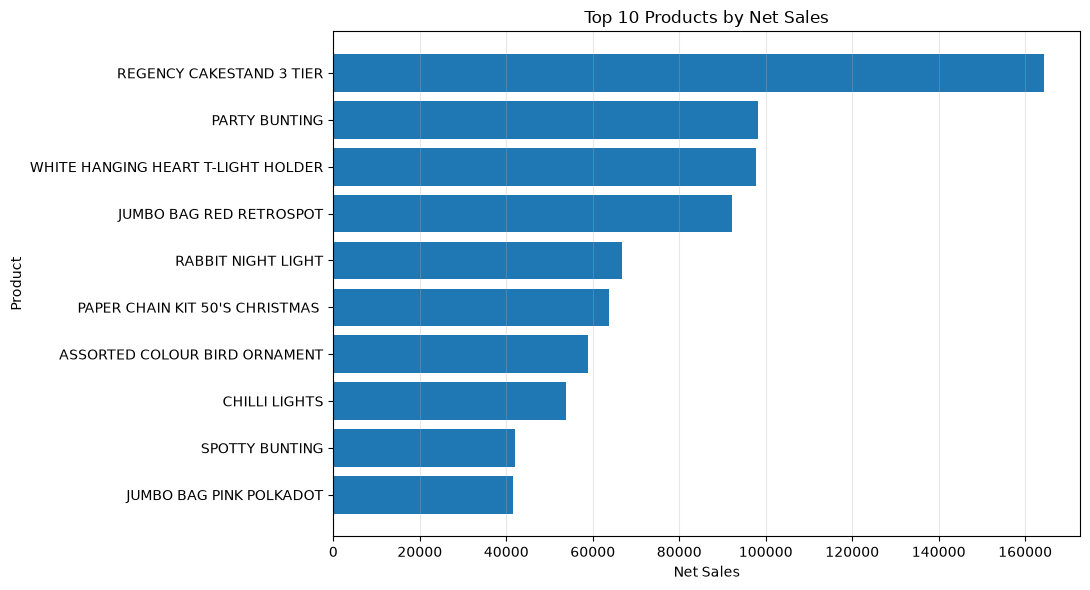

In [33]:
product_chart = (
    net_product_sales
    .head(10)
    .reset_index()
)

plt.figure(figsize=(11, 6))

plt.barh(
    product_chart['Description'],
    product_chart['TotalPrice']
)

plt.gca().invert_yaxis()

plt.title('Top 10 Products by Net Sales')
plt.xlabel('Net Sales')
plt.ylabel('Product')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

plt.savefig('top_products.png', dpi=150, bbox_inches='tight')
plt.show()

#### Product Sales Findings

- `REGENCY CAKESTAND 3 TIER` is the highest-performing product, generating approximately 164.5 thousand in net sales.
- `PARTY BUNTING` and `WHITE HANGING HEART T-LIGHT HOLDER` rank second and third with similar net sales.
- Product `23843` does not appear because its unusually large transaction was completely cancelled.
- Using net sales provides a more accurate product ranking than gross sales.

### 6.4 Top Customers by Net Sales

This chart displays the ten customers generating the highest total net sales after cancellations and returns.

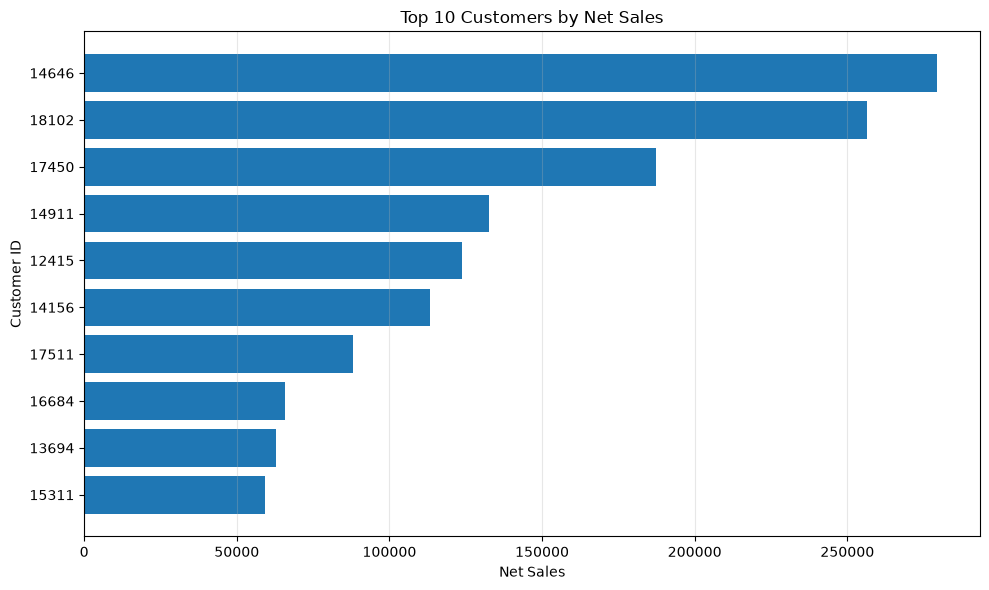

In [34]:
customer_chart = customer_summary_df.head(10).copy()

customer_chart['CustomerID'] = (
    customer_chart['CustomerID'].astype(str)
)

plt.figure(figsize=(10, 6))

plt.barh(
    customer_chart['CustomerID'],
    customer_chart['net_sales']
)

plt.gca().invert_yaxis()

plt.title('Top 10 Customers by Net Sales')
plt.xlabel('Net Sales')
plt.ylabel('Customer ID')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

plt.savefig('top_customers_net_sales.png', dpi=150, bbox_inches='tight')
plt.show()

#### Customer Net Sales Findings

- Customer `14646` generates the highest net sales at approximately 279.5 thousand.
- Customer `18102` ranks second with approximately 256.4 thousand.
- Customer `17450` ranks third, with a noticeable gap from the top two customers.
- The results show that a relatively small group of customers contributes a significant amount of revenue.

### 6.5 Top Customers by Average Order Value

This chart compares customers with the highest average order value.

Only customers with at least five purchase invoices are included to reduce the effect of unusually large one-time purchases.

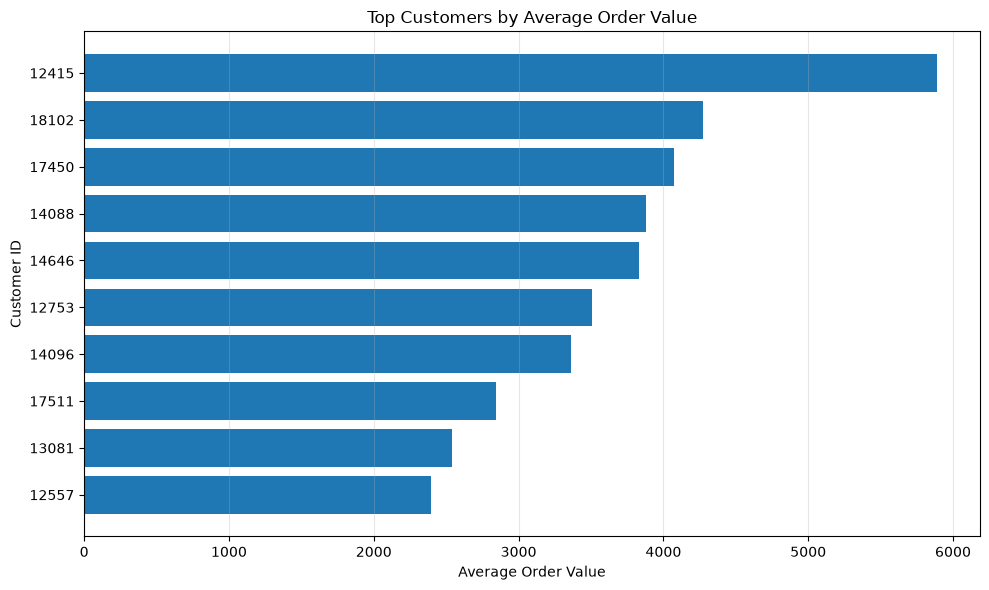

In [35]:
avg_order_chart = top_avg_customers.head(10).copy()

avg_order_chart['CustomerID'] = (
    avg_order_chart['CustomerID'].astype(str)
)

plt.figure(figsize=(10, 6))

plt.barh(
    avg_order_chart['CustomerID'],
    avg_order_chart['avg_order_value']
)

plt.gca().invert_yaxis()

plt.title('Top Customers by Average Order Value')
plt.xlabel('Average Order Value')
plt.ylabel('Customer ID')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

plt.savefig('top_customers_avg_order.png', dpi=150, bbox_inches='tight')
plt.show()

#### Average Order Value Findings

- Customer `12415` has the highest average order value at approximately 5,891.69.
- Customers `18102` and `17450` rank second and third.
- Customer `14646` generates the highest total net sales but ranks fifth by average order value.
- This confirms that total customer spending and average order value measure different aspects of customer value.

## 7. Conclusion

The analysis produced the following key findings:

- The dataset contained 541,909 rows before cleaning.
- A total of 5,268 exact duplicate rows were removed.
- Gross sales were approximately 10.64 million.
- Net sales after cancellations and returns were approximately 9.75 million.
- Cancellations and returns reduced revenue by approximately 893.98 thousand, or 8.4%.
- November 2011 was the strongest complete month, generating approximately 1.46 million in net sales.
- The United Kingdom generated approximately 84% of total net sales.
- `REGENCY CAKESTAND 3 TIER` was the highest-performing physical product by net sales.
- Customer `14646` generated the highest total net sales.
- Customer `12415` had the highest average order value among customers with at least five purchases.

Overall, the analysis demonstrates the importance of accounting for duplicates, cancellations, returns, incomplete time periods, and non-product transactions before evaluating e-commerce performance.

## 8. Exporting Results

The main analysis tables are exported as CSV files so they can be reused in dashboards, reports, or further analysis.

In [36]:
monthly_net_sales.to_csv(
    'monthly_net_sales.csv',
    index=False
)

country_net_sales.to_csv(
    'country_net_sales.csv',
    index=False
)

net_product_sales.reset_index().to_csv(
    'net_product_sales.csv',
    index=False
)

customer_summary_df.to_csv(
    'customer_summary.csv',
    index=False
)

top_avg_customers.to_csv(
    'top_average_order_customers.csv',
    index=False
)

print('All result files were exported successfully.')

All result files were exported successfully.
